<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data

---



In [4]:
!pip -q install transformers datasets accelerate evaluate rouge_score nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch
from peft import LoraConfig, get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [5]:
dataset = load_dataset("flaviagiammarino/vqa-rad")
print(dataset)

# train and test already available
train_ds = dataset["train"]
test_ds  = dataset["test"]


README.md:   0%|          | 0.00/3.91k [00:00<?, ?B/s]

data/train-00000-of-00001-eb8844602202be(…): reconstructing file:   0%|          |  0.00B / 24.2MB            

data/train-00000-of-00001-eb8844602202be(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-e5bc3d208bb4dee(…): reconstructing file:   0%|          |  0.00B / 10.3MB            

data/test-00000-of-00001-e5bc3d208bb4dee(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})


In [6]:
train_df = pd.DataFrame(train_ds)
test_df  = pd.DataFrame(test_ds)
train_df.head()

,image,question,answer
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,are regions of the brain infarcted?,yes
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,are the lungs normal appearing?,no
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,which organ system is abnormal in this image?,cardiovascular
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,is the lesion causing significant brainstem he...,no
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,how was this image taken?,mri


In [7]:
def clean_df(df):
    df = df.copy()

    # remove duplicates
    df = df.drop_duplicates(subset=["question", "answer"])

    # clean text
    df["question"] = df["question"].astype(str).str.strip()
    df["answer"] = (
        df["answer"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # remove empty rows
    df = df[(df["question"] != "") & (df["answer"] != "")]
    return df.reset_index(drop=True)

train_df = clean_df(train_df)
test_df  = clean_df(test_df)

print("Cleaned train:", len(train_df))
print("Cleaned test :", len(test_df))

Cleaned train: 1691
Cleaned test : 437


answer
yes        438
no         417
axial       27
right       20
left        13
pa          12
ct           9
fat          7
diffuse      7
Name: count, dtype: int64


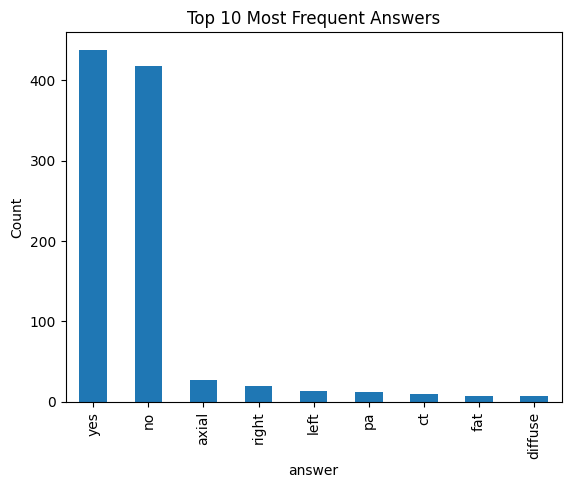

In [8]:
common_answers = train_df["answer"].value_counts().head(9)

print(common_answers)

common_answers.plot(kind="bar")
plt.title("Top 10 Most Frequent Answers")
plt.ylabel("Count")
plt.show()

In [9]:
closed_answers = {"yes", "no","left", "right","pa","ct","axial"}

def classify_answer(ans):
    return "closed" if ans in closed_answers else "open"

train_df["answer_type"] = train_df["answer"].apply(classify_answer)
test_df["answer_type"]  = test_df["answer"].apply(classify_answer)

train_df[["question", "answer", "answer_type"]].head()

,question,answer,answer_type
0,are regions of the brain infarcted?,yes,closed
1,are the lungs normal appearing?,no,closed
2,which organ system is abnormal in this image?,cardiovascular,open
3,is the lesion causing significant brainstem he...,no,closed
4,how was this image taken?,mri,open


In [10]:
train_df["answer_type"].value_counts()

,count
answer_type,
closed,936
open,755


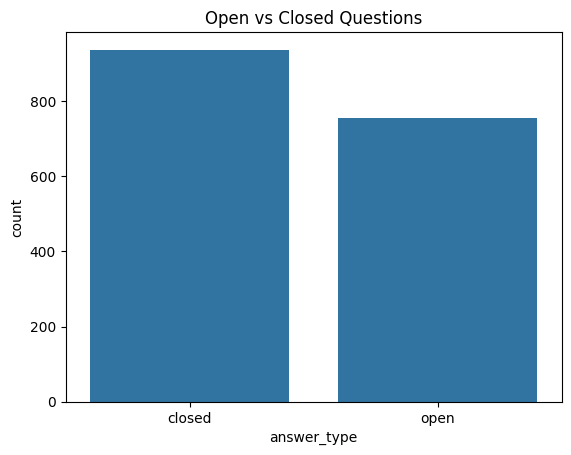

In [11]:
sns.countplot(data=train_df, x="answer_type")
plt.title("Open vs Closed Questions")
plt.show()

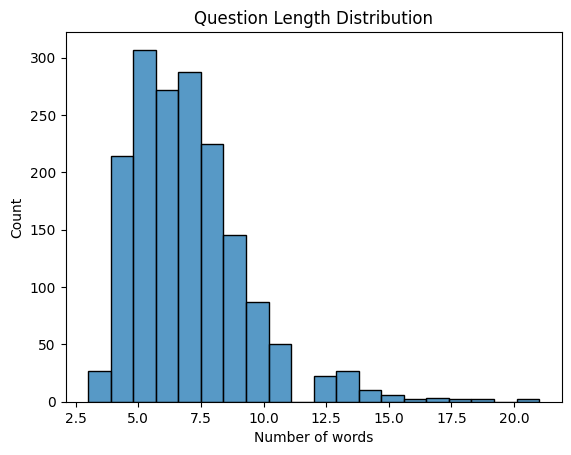

In [12]:
train_df["q_len"] = train_df["question"].apply(lambda x: len(x.split()))

sns.histplot(train_df["q_len"], bins=20)
plt.title("Question Length Distribution")
plt.xlabel("Number of words")
plt.show()

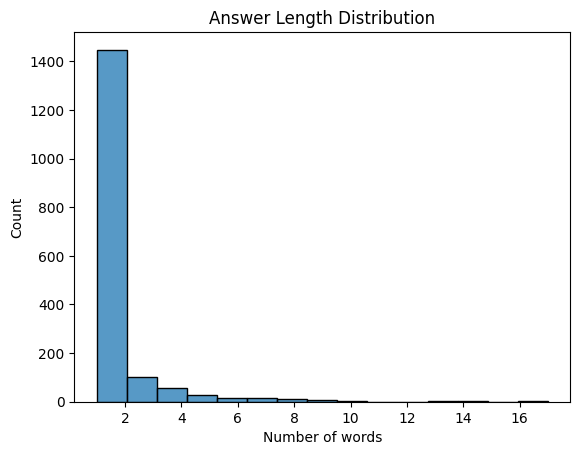

In [13]:
train_df["a_len"] = train_df["answer"].apply(lambda x: len(x.split()))

sns.histplot(train_df["a_len"], bins=15)
plt.title("Answer Length Distribution")
plt.xlabel("Number of words")
plt.show()

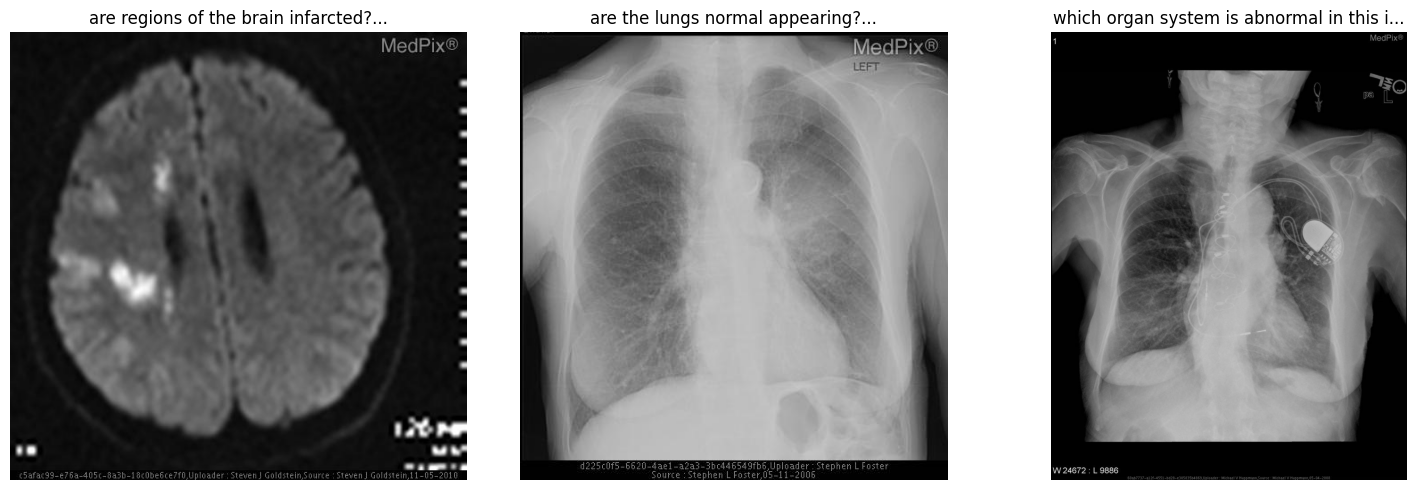

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, ax in enumerate(axes):
    sample = train_ds[i]
    ax.imshow(sample["image"])
    ax.set_title(sample["question"][:40] + "...")
    ax.axis("off")

plt.tight_layout()
plt.show()

#BLIP-VQA

In [15]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")

model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
).to(device)

print("Using device:", device)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Using device: cpu


In [16]:
def predict_answer(image, question):
    inputs = processor(
        image,
        question,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10
        )

    pred = processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return pred.strip().lower()

In [17]:
sample = test_ds[0]

pred = predict_answer(sample["image"], sample["question"])

print("Question :", sample["question"])
print("GT Answer:", sample["answer"])
print("Prediction:", pred)

Question : is there evidence of an aortic aneurysm?
GT Answer: yes
Prediction: yes


In [18]:
preds = []
gts = []
types = []

for item in test_ds:
    pred = predict_answer(item["image"], item["question"])

    gt = item["answer"].strip().lower()
    qtype = classify_answer(gt)

    preds.append(pred)
    gts.append(gt)
    types.append(qtype)

results = pd.DataFrame({
    "prediction": preds,
    "ground_truth": gts,
    "answer_type": types
})

results.head()

,prediction,ground_truth,answer_type
0,yes,yes,closed
1,no,yes,closed
2,yes,no,closed
3,right,right,closed
4,in lower right,not seen here,open


In [19]:
# exact match
results["correct"] = (
    results["prediction"] == results["ground_truth"]
)

# combined accuracy
combined_acc = results["correct"].mean()

# open-ended accuracy
open_acc = results[
    results["answer_type"] == "open"
]["correct"].mean()

# closed-ended accuracy
closed_acc = results[
    results["answer_type"] == "closed"
]["correct"].mean()

print(f"Combined Accuracy : {combined_acc:.4f}")
print(f"Open-ended Accuracy : {open_acc:.4f}")
print(f"Closed-ended Accuracy : {closed_acc:.4f}")

Combined Accuracy : 0.3304
Open-ended Accuracy : 0.0233
Closed-ended Accuracy : 0.5197


In [20]:
from sklearn.metrics import f1_score

f1_macro = f1_score(
    results["ground_truth"],
    results["prediction"],
    average="macro",
    zero_division=0
)

print(f"Macro F1 Score : {f1_macro:.4f}")

Macro F1 Score : 0.0218


In [21]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

bleu_scores = []

for pred, gt in zip(
    results["prediction"],
    results["ground_truth"]
):
    reference = [gt.split()]
    candidate = pred.split()

    score = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smooth
    )

    bleu_scores.append(score)

bleu_avg = np.mean(bleu_scores)

print(f"Average BLEU Score : {bleu_avg:.4f}")

Average BLEU Score : 0.0617


In [22]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rougeL'],
    use_stemmer=True
)

rouge_scores = []

for pred, gt in zip(
    results["prediction"],
    results["ground_truth"]
):
    score = scorer.score(gt, pred)["rougeL"].fmeasure
    rouge_scores.append(score)

rougeL_avg = np.mean(rouge_scores)

print(f"Average ROUGE-L : {rougeL_avg:.4f}")

Average ROUGE-L : 0.3493


In [23]:
benchmark_df = pd.DataFrame({
    "Metric": [
        "Combined Accuracy",
        "Open-ended Accuracy",
        "Closed-ended Accuracy",
        "Macro F1 Score",
        "BLEU",
        "ROUGE-L"
    ],
    "BLIP Zero-shot": [
        round(combined_acc, 4),
        round(open_acc, 4),
        round(closed_acc, 4),
        round(f1_macro, 4),
        round(bleu_avg, 4),
        round(rougeL_avg, 4)
    ]
})

benchmark_df

,Metric,BLIP Zero-shot
0,Combined Accuracy,0.3304
1,Open-ended Accuracy,0.0233
2,Closed-ended Accuracy,0.5197
3,Macro F1 Score,0.0218
4,BLEU,0.0617
5,ROUGE-L,0.3493


#Qwen2-VL-2B-Instruct

In [ ]:
!pip -q install transformers accelerate qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 21.1 MB/s eta 0:00:00


In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
model_id = "Qwen/Qwen2-VL-2B-Instruct"

# load model
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

# load processor
processor = AutoProcessor.from_pretrained(model_id)
print("Model loaded on:", device)

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Model loaded on: cuda


In [ ]:
def predict_answer(image, question):

    prompt = (
        "You are a radiologist. "
        "Answer the medical visual question using a short and precise medical term or phrase. "
        f"Question: {question}"
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    # create chat template
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # process inputs
    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    # generate answer
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=15,
            do_sample=False,
            temperature=0.0
        )

    # remove input tokens from output
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    response = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0]

    return response.strip().lower()

In [ ]:
for i in range(5):
    item = test_ds[i]

    pred = predict_answer(item["image"], item["question"])

    print(f"[{i}]")
    print("Q :", item["question"])
    print("GT:", item["answer"])
    print("PR:", pred)
    print("-"*60)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[0]
Q : is there evidence of an aortic aneurysm?
GT: yes
PR: no
------------------------------------------------------------
[1]
Q : is there airspace consolidation on the left side?
GT: yes
PR: yes
------------------------------------------------------------
[2]
Q : is there any intraparenchymal abnormalities in the lung fields?
GT: no
PR: no
------------------------------------------------------------
[3]
Q : which side of the heart border is obscured?
GT: right
PR: the right side of the heart border is obscured.
------------------------------------------------------------
[4]
Q : where are the kidney?
GT: not seen here
PR: the kidneys are located in the upper abdomen, just below the spine.
------------------------------------------------------------


In [ ]:
preds = []
gts = []
types = []

for idx, item in enumerate(test_ds):

    pred = predict_answer(item["image"], item["question"])

    gt = item["answer"].strip().lower()
    qtype = classify_answer(gt)

    preds.append(pred)
    gts.append(gt)
    types.append(qtype)

    # progress print every 20 samples
    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(test_ds)} samples")

results = pd.DataFrame({
    "prediction": preds,
    "ground_truth": gts,
    "answer_type": types
})

results.head()

Processed 20/451 samples
Processed 40/451 samples
Processed 60/451 samples
Processed 80/451 samples
Processed 100/451 samples
Processed 120/451 samples
Processed 140/451 samples
Processed 160/451 samples
Processed 180/451 samples
Processed 200/451 samples
Processed 220/451 samples
Processed 240/451 samples
Processed 260/451 samples
Processed 280/451 samples
Processed 300/451 samples
Processed 320/451 samples
Processed 340/451 samples
Processed 360/451 samples
Processed 380/451 samples
Processed 400/451 samples
Processed 420/451 samples
Processed 440/451 samples


,prediction,ground_truth,answer_type
0,no,yes,closed
1,yes,yes,closed
2,no,no,closed
3,the right side of the heart border is obscured.,right,closed
4,"the kidneys are located in the upper abdomen, ...",not seen here,open


In [ ]:
results["correct"] = (
    results["prediction"] == results["ground_truth"]
)

combined_acc = results["correct"].mean()

open_acc = results[
    results["answer_type"] == "open"
]["correct"].mean()

closed_acc = results[
    results["answer_type"] == "closed"
]["correct"].mean()

print(f"Combined Accuracy : {combined_acc:.4f}")
print(f"Open-ended Accuracy : {open_acc:.4f}")
print(f"Closed-ended Accuracy : {closed_acc:.4f}")

Combined Accuracy : 0.3858
Open-ended Accuracy : 0.0872
Closed-ended Accuracy : 0.5699


In [ ]:
from sklearn.metrics import f1_score

f1_macro = f1_score(
    results["ground_truth"],
    results["prediction"],
    average="macro",
    zero_division=0
)

print(f"Macro F1 Score : {f1_macro:.4f}")

Macro F1 Score : 0.0323


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

bleu_scores = []

for pred, gt in zip(results["prediction"], results["ground_truth"]):

    reference = [gt.split()]
    candidate = pred.split()

    score = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smooth
    )

    bleu_scores.append(score)

bleu_avg = np.mean(bleu_scores)

print(f"Average BLEU Score : {bleu_avg:.4f}")

Average BLEU Score : 0.0745


In [ ]:
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(
    ['rougeL'],
    use_stemmer=True
)

rouge_scores = []

for pred, gt in zip(results["prediction"], results["ground_truth"]):

    score = scorer.score(gt, pred)["rougeL"].fmeasure
    rouge_scores.append(score)

rougeL_avg = np.mean(rouge_scores)

print(f"Average ROUGE-L : {rougeL_avg:.4f}")

Average ROUGE-L : 0.4350


In [ ]:
benchmark_df = pd.DataFrame({
    "Metric": [
        "Combined Accuracy",
        "Open-ended Accuracy",
        "Closed-ended Accuracy",
        "Macro F1 Score",
        "BLEU",
        "ROUGE-L"
    ],
    "Qwen2-VL-2B-Instruct": [
        round(combined_acc, 4),
        round(open_acc, 4),
        round(closed_acc, 4),
        round(f1_macro, 4),
        round(bleu_avg, 4),
        round(rougeL_avg, 4)
    ]
})

benchmark_df

,Metric,Qwen2-VL-2B-Instruct
0,Combined Accuracy,0.3858
1,Open-ended Accuracy,0.0872
2,Closed-ended Accuracy,0.5699
3,Macro F1 Score,0.0323
4,BLEU,0.0745
5,ROUGE-L,0.4350


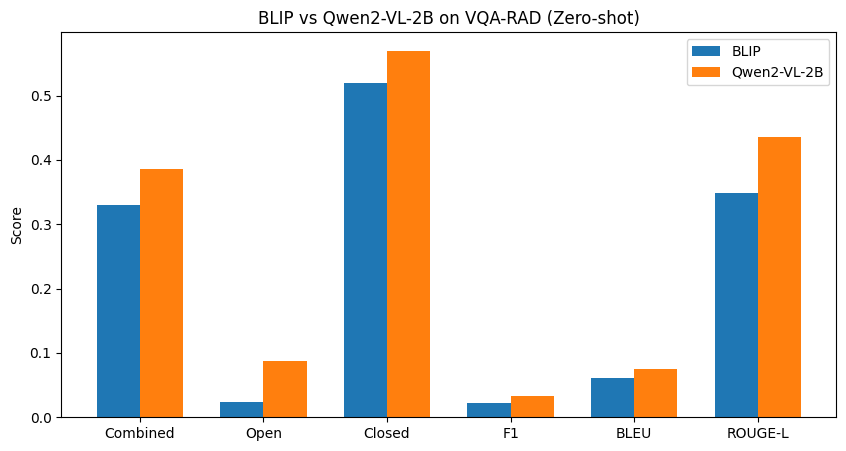

In [ ]:
metrics = [
    "Combined", "Open", "Closed",
    "F1", "BLEU", "ROUGE-L"
]

blip_scores = [0.3304, 0.0233, 0.5197, 0.0218, 0.0617, 0.3493]
qwen_scores = [0.3858, 0.0872, 0.5699, 0.0323, 0.0745, 0.4350]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar([i - width/2 for i in x], blip_scores, width, label="BLIP")
plt.bar([i + width/2 for i in x], qwen_scores, width, label="Qwen2-VL-2B")

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("BLIP vs Qwen2-VL-2B on VQA-RAD (Zero-shot)")
plt.legend()
plt.show()

#Fine Tune

In [12]:
!pip -q install git+https://github.com/huggingface/transformers accelerate peft bitsandbytes datasets trl qwen-vl-utils

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 27.9 MB/s eta 0:00:00


In [13]:
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    model_id,
    min_pixels=256*28*28,
    max_pixels=512*28*28
)

print("Model loaded!")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Model loaded!


In [14]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [15]:
def format_example(example):

    prompt = (
        "You are a radiologist. "
        "Answer the medical visual question with a short and precise medical term.\n"
        f"Question: {example['question']}"
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": example["image"]},
                {"type": "text", "text": prompt},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": example["answer"].lower()}
            ],
        },
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    return {
        "text": text,
        "image": example["image"]
    }

train_processed = train_ds.map(format_example)
test_processed  = test_ds.map(format_example)

train_processed[0]["text"][:500]

Map:   0%|          | 0/1793 [00:00<?, ? examples/s]

Map:   0%|          | 0/451 [00:00<?, ? examples/s]

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>You are a radiologist. Answer the medical visual question with a short and precise medical term.\nQuestion: are regions of the brain infarcted?<|im_end|>\n<|im_start|>assistant\nyes<|im_end|>\n'

In [16]:
def collate_fn(examples):

    texts  = [ex["text"] for ex in examples]
    images = [ex["image"] for ex in examples]

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    batch["labels"] = labels

    return batch

In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qwen25-vl-vqa-rad",

    num_train_epochs=1,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=2e-4,
    warmup_ratio=0.05,

    logging_steps=10,
    save_strategy="epoch",

    fp16=True,

    remove_unused_columns=False,
    report_to="none"
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [18]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_processed,
    data_collator=collate_fn
)

trainer.train()

Step,Training Loss
10,17.227841
20,9.924277
30,7.146365
40,6.987083
50,6.947047
60,6.908221
70,6.921181
80,6.931898
90,6.946951
100,6.872694


TrainOutput(global_step=225, training_loss=7.521422763400608, metrics={'train_runtime': 2744.1328, 'train_samples_per_second': 0.653, 'train_steps_per_second': 0.082, 'total_flos': 1.8048101760086016e+16, 'train_loss': 7.521422763400608, 'epoch': 1.0})

In [19]:
trainer.model.save_pretrained("/content/qwen25-vl-vqa-rad-lora")
processor.save_pretrained("/content/qwen25-vl-vqa-rad-lora")

['/content/qwen25-vl-vqa-rad-lora/processor_config.json']

In [20]:
from peft import PeftModel

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto"
)

ft_model = PeftModel.from_pretrained(
    base_model,
    "./qwen25-vl-vqa-rad-lora"
)

ft_model.eval()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
                (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=1280, out_features=3420, 

In [21]:
import torch

def predict_answer(image, question):

    prompt = (
        "You are a radiologist. "
        "Answer the medical visual question using a short and precise medical term or phrase.\n"
        f"Question: {question}"
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=15,
            do_sample=False,
            temperature=0.0
        )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    response = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0]

    return response.strip().lower()

In [22]:
CLOSED_ANSWERS = {
    "yes", "no",
    "left", "right",
    "pa","ct","axial"
}

def classify_answer(ans):
    return "closed" if ans in CLOSED_ANSWERS else "open"

In [23]:
preds = []
gts = []
types = []

for idx, item in enumerate(test_ds):

    pred = predict_answer(item["image"], item["question"])

    gt = item["answer"].strip().lower()
    qtype = classify_answer(gt)

    preds.append(pred)
    gts.append(gt)
    types.append(qtype)

    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(test_ds)} samples")

results = pd.DataFrame({
    "prediction": preds,
    "ground_truth": gts,
    "answer_type": types
})

results.head()

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Processed 20/451 samples
Processed 40/451 samples
Processed 60/451 samples
Processed 80/451 samples
Processed 100/451 samples
Processed 120/451 samples
Processed 140/451 samples
Processed 160/451 samples
Processed 180/451 samples
Processed 200/451 samples
Processed 220/451 samples
Processed 240/451 samples
Processed 260/451 samples
Processed 280/451 samples
Processed 300/451 samples
Processed 320/451 samples
Processed 340/451 samples
Processed 360/451 samples
Processed 380/451 samples
Processed 400/451 samples
Processed 420/451 samples
Processed 440/451 samples


,prediction,ground_truth,answer_type
0,no,yes,closed
1,no,yes,closed
2,no,no,closed
3,right,right,closed
4,right,not seen here,open


In [24]:
results["correct"] = (
    results["prediction"] == results["ground_truth"]
)

combined_acc = results["correct"].mean()

open_acc = results[
    results["answer_type"] == "open"
]["correct"].mean()

closed_acc = results[
    results["answer_type"] == "closed"
]["correct"].mean()

print(f"Combined Accuracy     : {combined_acc:.4f}")
print(f"Open-ended Accuracy   : {open_acc:.4f}")
print(f"Closed-ended Accuracy : {closed_acc:.4f}")

Combined Accuracy     : 0.5499
Open-ended Accuracy   : 0.2267
Closed-ended Accuracy : 0.7491


In [25]:
from collections import Counter
import numpy as np

def token_f1(pred, gt):

    pred_tokens = pred.split()
    gt_tokens   = gt.split()

    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gt_tokens)

    return 2 * precision * recall / (precision + recall)

token_f1_scores = [
    token_f1(p, g)
    for p, g in zip(results.prediction, results.ground_truth)
]

token_f1_avg = np.mean(token_f1_scores)

print(f"Token-level F1 : {token_f1_avg:.4f}")

Token-level F1 : 0.5894


In [26]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rougeL'],
    use_stemmer=True
)

rouge_scores = []

for pred, gt in zip(results.prediction, results.ground_truth):

    score = scorer.score(gt, pred)["rougeL"].fmeasure
    rouge_scores.append(score)

rougeL_avg = np.mean(rouge_scores)

print(f"ROUGE-L : {rougeL_avg:.4f}")

ROUGE-L : 0.5936


In [27]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

bleu_scores = []

for pred, gt in zip(results.prediction, results.ground_truth):

    reference = [gt.split()]
    candidate = pred.split()

    score = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smooth
    )

    bleu_scores.append(score)

bleu_avg = np.mean(bleu_scores)

print(f"BLEU : {bleu_avg:.4f}")

BLEU : 0.1122


In [28]:
benchmark_df = pd.DataFrame({
    "Metric": [
        "Combined Accuracy",
        "Open-ended Accuracy",
        "Closed-ended Accuracy",
        "Token-level F1",
        "BLEU",
        "ROUGE-L"
    ],
    "Qwen2.5-VL-3B": [
        round(combined_acc, 4),
        round(open_acc, 4),
        round(closed_acc, 4),
        round(token_f1_avg, 4),
        round(bleu_avg, 4),
        round(rougeL_avg, 4)
    ]
})

benchmark_df

,Metric,Qwen2.5-VL-3B
0,Combined Accuracy,0.5499
1,Open-ended Accuracy,0.2267
2,Closed-ended Accuracy,0.7491
3,Token-level F1,0.5894
4,BLEU,0.1122
5,ROUGE-L,0.5936


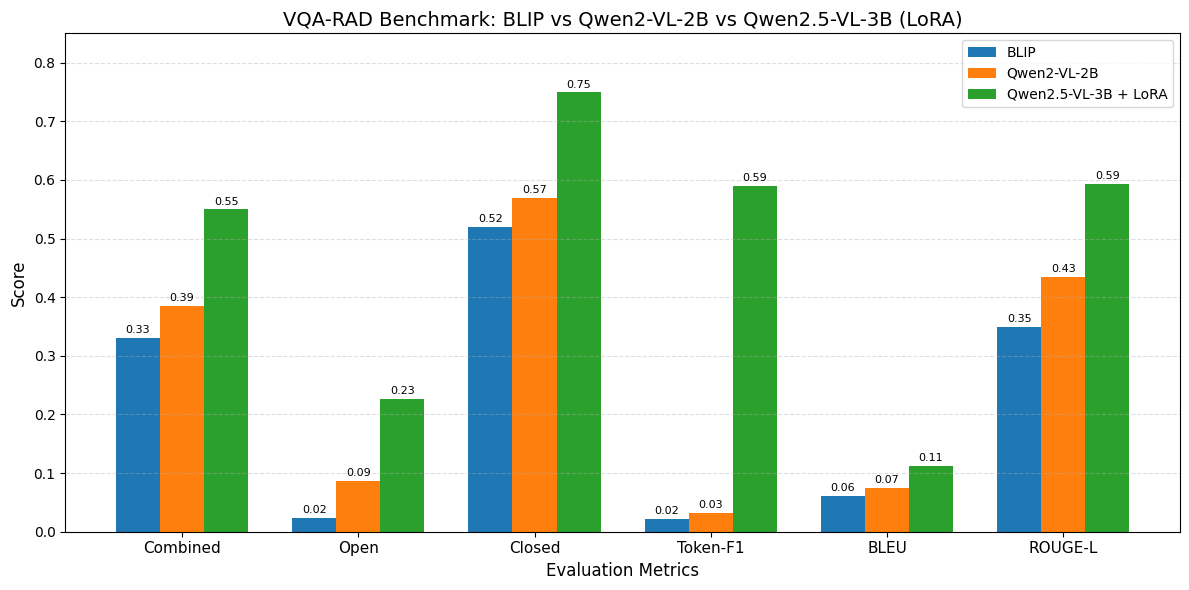

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = [
    "Combined",
    "Open",
    "Closed",
    "Token-F1",
    "BLEU",
    "ROUGE-L"
]

# BLIP scores
blip = [0.3304, 0.0233, 0.5197, 0.0218, 0.0617, 0.3493]

# Qwen2-VL-2B scores
qwen2b = [0.3858, 0.0872, 0.5699, 0.0323, 0.0745, 0.4350]

# Qwen2.5-VL-3B + LoRA scores
qwen25_3b = [0.5499, 0.2267, 0.7491, 0.5894, 0.1122, 0.5936]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, blip, width, label="BLIP")
plt.bar(x, qwen2b, width, label="Qwen2-VL-2B")
plt.bar(x + width, qwen25_3b, width, label="Qwen2.5-VL-3B + LoRA")

# Labels and title
plt.xticks(x, metrics, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.title("VQA-RAD Benchmark: BLIP vs Qwen2-VL-2B vs Qwen2.5-VL-3B (LoRA)", fontsize=14)

# Y-axis limit
plt.ylim(0, 0.85)

# Add value labels
for bars in plt.gca().containers:
    plt.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()